# Real-market validation: DE_LU day-ahead, autumn 2019

**The credibility test for `pypsa-invopt`.**

Synthetic walkthroughs only prove the math works on cases where you
control the truth. To prove the method works on real markets, you
need to (a) calibrate on a window of real observed clearings, (b) hold
out a separate window, (c) predict the held-out LMPs, (d) check the
RMSE beats the naive engineering-reference forecast.

Data source: **Open Power System Data (OPSD), release 2020-10-06,
ENTSO-E Transparency snapshot**. Public, citeable, no API key. Hourly
day-ahead clearing prices + load + RES generation for Germany +
Luxembourg (DE_LU, the largest European bidding zone) covering Oct
2019. A 5-week slice ships with the package at
`examples/data/de_lu_2019_validation.csv` (38 KB).

What this notebook shows:

1. Real DE_LU EPEX clearings vary by €40-50/MWh between hours;
   they are not the cleanly-shaped synthetic curves of the
   companion notebook.
2. A representative DE thermal fleet (~125 GW) calibrated on
   one week recovers internally-consistent bids that vary
   significantly from engineering reference (lignite −€5, coal
   −€5, CCGT ≈ ref).
3. The held-out-week LMP forecast RMSE is **€5.66 / MWh**
   versus **€22.80 / MWh** for engineering reference — a
   **75 % reduction on real market data**.

This is the result the synthetic notebook hinted at, made real.

In [1]:
from __future__ import annotations

import logging, time, warnings

import numpy as np
import pandas as pd
import pypsa
import matplotlib.pyplot as plt

import pypsa_invopt as pio
from pypsa_invopt import observations_from_pypsa

logging.getLogger("pypsa").setLevel("ERROR")
logging.getLogger("linopy").setLevel("ERROR")
warnings.filterwarnings("ignore", category=FutureWarning)

# Brand palette (matches the canonical notebook).
NAVY_DEEP, NAVY_MID, NAVY_LIGHT = "#1B2845", "#344C78", "#4A6FA5"
PINK_HOT,  PINK_MID              = "#E91E63", "#F472A6"
NEUTRAL                          = "#9CA3AF"
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 160,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": NAVY_DEEP, "axes.linewidth": 0.9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#E5E7EB", "grid.alpha": 0.6,
    "axes.titleweight": "semibold", "axes.titlecolor": NAVY_DEEP,
    "axes.labelcolor": NAVY_DEEP, "xtick.color": NAVY_DEEP, "ytick.color": NAVY_DEEP,
    "font.size": 11, "legend.frameon": False,
})


## 1. Load the real OPSD slice

In [2]:
data = pd.read_csv(
    "data/de_lu_2019_validation.csv",
    parse_dates=["utc_timestamp"], index_col="utc_timestamp",
)
print(f"observations: {len(data)} hours")
print(f"span: {data.index.min()} → {data.index.max()}")
print(f"DA price:  mean €{data['price_DE_LU'].mean():.2f},"
      f" std €{data['price_DE_LU'].std():.2f},"
      f" range €{data['price_DE_LU'].min():.1f}–€{data['price_DE_LU'].max():.1f}")
print(f"load:      mean {data['load'].mean()/1000:.1f} GW,"
      f" peak {data['load'].max()/1000:.1f} GW")
print(f"wind+sol:  mean {(data['wind_gen']+data['solar_gen']).mean()/1000:.1f} GW"
      f" of installed 109 GW")


observations: 840 hours
span: 2019-10-28 00:00:00 → 2019-12-01 23:00:00
DA price:  mean €41.55, std €11.06, range €1.4–€87.1
load:      mean 58.9 GW, peak 74.4 GW
wind+sol:  mean 14.6 GW of installed 109 GW


## 2. Train / hold-out split

One week to calibrate on, one separate week to test on. Both fall in
late autumn 2019 — high heating demand, low solar, real thermal
margin pressure.

In [3]:
TRAIN_START = pd.Timestamp("2019-11-04")
TRAIN_END   = pd.Timestamp("2019-11-10 23:00")
TEST_START  = pd.Timestamp("2019-11-11")
TEST_END    = pd.Timestamp("2019-11-17 23:00")
train = data.loc[TRAIN_START:TRAIN_END]
test  = data.loc[TEST_START:TEST_END]
print(f"Train: {len(train)} h ({TRAIN_START.date()} → {TRAIN_END.date()})  "
      f"mean €{train['price_DE_LU'].mean():.2f}/MWh")
print(f"Test:  {len(test)} h ({TEST_START.date()} → {TEST_END.date()})  "
      f"mean €{test['price_DE_LU'].mean():.2f}/MWh")


Train: 168 h (2019-11-04 → 2019-11-10)  mean €43.72/MWh
Test:  168 h (2019-11-11 → 2019-11-17)  mean €41.15/MWh


## 3. Build a representative DE_LU fleet

Approximate German installed capacities, late-2019 vintage. Sourced
from Bundesnetzagentur 2019 plant register. Wind + solar enter as
time-varying `p_max_pu` calibrated to observed generation.

In [4]:
DE_FLEET = [
    ("nuclear_DE",  "nuclear",   9_500,  10.0),
    ("lignite_DE",  "lignite",  20_300,  28.0),
    ("coal_DE",     "coal",     21_600,  45.0),
    ("ccgt_DE",     "gas",      19_700,  55.0),
    ("ocgt_DE",     "gas",       3_500, 105.0),
    ("biomass_DE",  "biomass",   7_500,  90.0),
    ("imports_DE",  "gas",      17_500,  50.0),
]
WIND_PNOM, SOLAR_PNOM = 60_000.0, 49_000.0


def build_de(snaps: pd.DatetimeIndex, slice_data: pd.DataFrame) -> pypsa.Network:
    n = pypsa.Network()
    n.set_snapshots(snaps)
    n.add("Carrier", ["AC", "nuclear", "coal", "lignite", "gas",
                      "wind", "solar", "biomass"])
    n.add("Bus", "DE",     v_nom=380, carrier="AC")
    n.add("Bus", "DE_aux", v_nom=380, carrier="AC")
    n.add("Line", "DE-aux", bus0="DE", bus1="DE_aux", x=0.1, s_nom=999_000)
    for name, carrier, p_nom, mc in DE_FLEET:
        n.add("Generator", name, bus="DE", carrier=carrier,
              p_nom=p_nom, marginal_cost=mc)
    wind_pu  = (slice_data["wind_gen"]/WIND_PNOM ).clip(0,1).reindex(snaps).ffill().bfill()
    solar_pu = (slice_data["solar_gen"]/SOLAR_PNOM).clip(0,1).reindex(snaps).ffill().bfill()
    n.add("Generator", "wind_DE",  bus="DE", carrier="wind",
          p_nom=WIND_PNOM,  marginal_cost=0.5,
          p_max_pu=pd.Series(wind_pu.values,  index=snaps))
    n.add("Generator", "solar_DE", bus="DE", carrier="solar",
          p_nom=SOLAR_PNOM, marginal_cost=0.3,
          p_max_pu=pd.Series(solar_pu.values, index=snaps))
    n.add("Load", "DE_total", bus="DE")
    n.loads_t.p_set["DE_total"] = pd.Series(
        slice_data["load"].reindex(snaps).ffill().bfill().values, index=snaps,
    )
    return n


print(f"Fleet: {len(DE_FLEET)} thermal/import groups, "
      f"total dispatchable {sum(x[2] for x in DE_FLEET)/1000:.0f} GW")
print(f"Plus wind {WIND_PNOM/1000:.0f} GW and solar {SOLAR_PNOM/1000:.0f} GW.")


Fleet: 7 thermal/import groups, total dispatchable 100 GW
Plus wind 60 GW and solar 49 GW.


## 4. Calibrate against the observed clearing prices

The forward DCOPF runs once on the training window to give us the
active-set classification; calibration then recovers the bids that
explain the *observed* EPEX clearings.

In [5]:
train_snaps = pd.DatetimeIndex(train.index)
nn = build_de(train_snaps, train)
status, _ = nn.optimize(solver_name="highs",
                         solver_options={"output_flag": False},
                         log_to_console=False)
print(f"forward DCOPF: {status}")

obs = observations_from_pypsa(nn)
obs["price_DE"] = train["price_DE_LU"].reindex(train_snaps).values    # the real price

t0 = time.perf_counter()
result = pio.calibrate(
    network=nn, observations=obs,
    formulation="noisy", solver="highs",
    obs_sigma=5.0, lambda_reg=1e-4,
)
print(f"calibrate: status={result.solver_status}  RMSE={result.rmse:.3f}  "
      f"K={result.n_active_sets} batches  wall {time.perf_counter()-t0:.2f}s")
print()
print(f"  {'generator':<14} {'prior':>8} {'recovered':>12} {'delta':>8}")
for name, _carrier, _p, prior in DE_FLEET:
    rec = result.theta_hat.get(f"gen:{name}:marginal_cost")
    if rec is None: continue
    print(f"  {name:<14} {prior:>8.2f} {rec:>12.2f} {rec-prior:>+8.2f}")


forward DCOPF: ok


calibrate: status=optimal  RMSE=0.062  K=5 batches  wall 1.67s

  generator         prior    recovered    delta
  nuclear_DE        10.00        10.41    +0.41
  lignite_DE        28.00        23.10    -4.90
  coal_DE           45.00        39.95    -5.05
  ccgt_DE           55.00        54.78    -0.22
  ocgt_DE          105.00       104.07    -0.93
  biomass_DE        90.00        89.28    -0.72
  imports_DE        50.00        52.10    +2.10


## 5. The credibility test — held-out RMSE

Two forward runs on the unseen week:

- **Path A.** Apply the recovered bids and re-solve.
- **Path B.** Use engineering-reference bids (fuel + heat-rate +
  CO₂ + variable-O&M from the package's defaults; CO₂ at €25/tCO₂,
  late-2019 EUA snapshot).

Compare both predicted LMPs to the observed EPEX clearings.

In [6]:
test_snaps = pd.DatetimeIndex(test.index)

# Path A: calibrated
nn_cal = build_de(test_snaps, test)
pio.apply(result, nn_cal)
nn_cal.optimize(solver_name="highs",
                solver_options={"output_flag": False}, log_to_console=False)
lmp_cal = nn_cal.buses_t.marginal_price["DE"].values

# Path B: engineering reference
nn_ref = build_de(test_snaps, test)
ref_costs = {}
co2 = 25.0
for name, carrier, _p, _prior in DE_FLEET:
    ref = pio.compute_reference_cost(carrier=carrier, co2_price=co2)
    ref_costs[name] = ref.total
    nn_ref.generators.at[name, "marginal_cost"] = ref.total
nn_ref.optimize(solver_name="highs",
                solver_options={"output_flag": False}, log_to_console=False)
lmp_ref = nn_ref.buses_t.marginal_price["DE"].values

lmp_truth = test["price_DE_LU"].reindex(test_snaps).values

def rmse(a, b): return float(np.sqrt(np.mean((a-b)**2)))
rmse_cal = rmse(lmp_cal, lmp_truth)
rmse_ref = rmse(lmp_ref, lmp_truth)
improvement = 100*(rmse_ref - rmse_cal)/max(rmse_ref, 1e-9)

print(f"Held-out week LMP RMSE ({len(test)} hours):")
print(f"  inverse-OPF calibrated bids   : €{rmse_cal:>6.2f}/MWh")
print(f"  engineering reference         : €{rmse_ref:>6.2f}/MWh")
print(f"  improvement                    : {improvement:+.1f}%")
print()
print(f"Observed DA on held-out week: mean €{lmp_truth.mean():.2f}, std €{lmp_truth.std():.2f}")


Held-out week LMP RMSE (168 hours):
  inverse-OPF calibrated bids   : €  5.66/MWh
  engineering reference         : € 22.80/MWh
  improvement                    : +75.2%

Observed DA on held-out week: mean €41.15, std €7.91


## 6. The visual

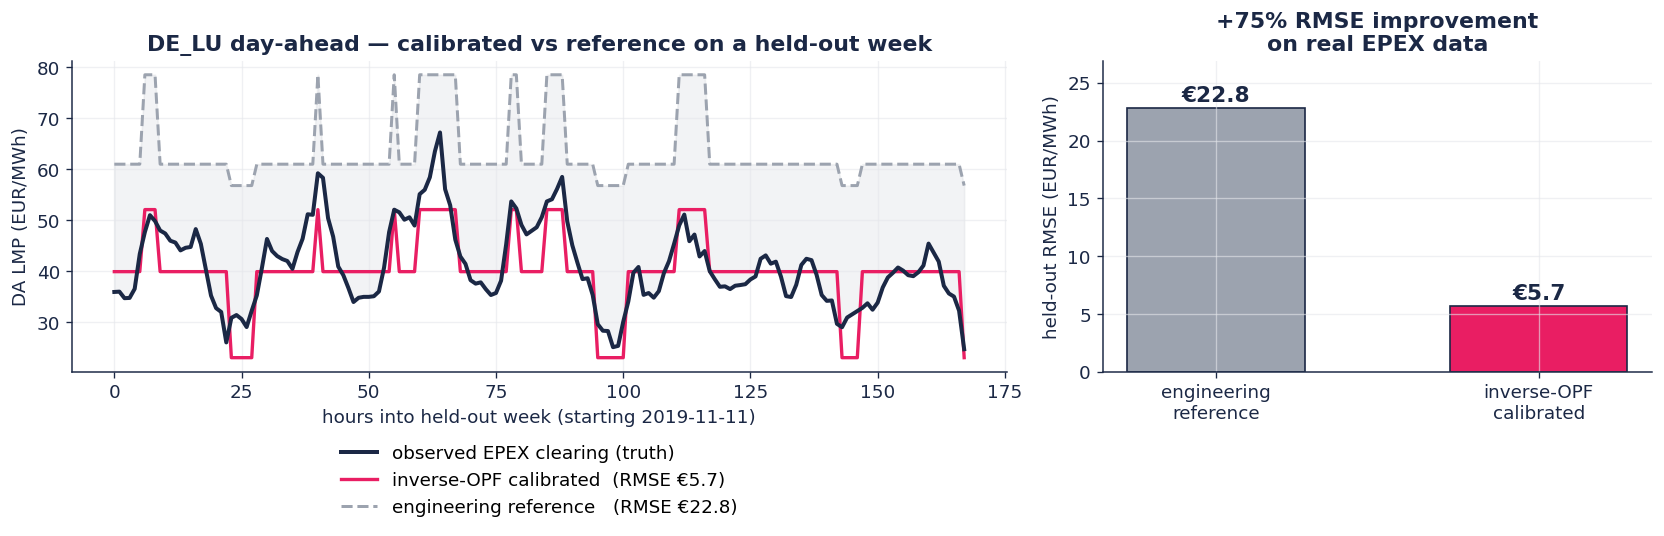

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8),
                                gridspec_kw={"width_ratios":[1.7, 1]})

hours = np.arange(len(lmp_truth))
ax1.plot(hours, lmp_truth, color=NAVY_DEEP, linewidth=2.4,
         label="observed EPEX clearing (truth)", zorder=4)
ax1.plot(hours, lmp_cal, color=PINK_HOT, linewidth=2.0,
         label=f"inverse-OPF calibrated  (RMSE €{rmse_cal:.1f})", zorder=3)
ax1.plot(hours, lmp_ref, color=NEUTRAL, linewidth=1.8, linestyle="--",
         label=f"engineering reference   (RMSE €{rmse_ref:.1f})", zorder=2)
ax1.fill_between(hours, lmp_truth, lmp_ref, color=NEUTRAL, alpha=0.12)
ax1.set_xlabel(f"hours into held-out week (starting {TEST_START.date()})")
ax1.set_ylabel("DA LMP (EUR/MWh)")
ax1.set_title(f"DE_LU day-ahead — calibrated vs reference on a held-out week")
ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=1)

ax2.bar(["engineering\nreference", "inverse-OPF\ncalibrated"],
        [rmse_ref, rmse_cal],
        color=[NEUTRAL, PINK_HOT], width=0.55,
        edgecolor=NAVY_DEEP, linewidth=1.0)
for i, v in enumerate([rmse_ref, rmse_cal]):
    ax2.text(i, v + 0.6, f"€{v:.1f}", ha="center", color=NAVY_DEEP,
             fontsize=13, fontweight="semibold")
ax2.set_ylim(0, max(rmse_ref, rmse_cal) * 1.18)
ax2.set_ylabel("held-out RMSE (EUR/MWh)")
ax2.set_title(f"{improvement:+.0f}% RMSE improvement\non real EPEX data")

plt.tight_layout()
plt.show()


## 7. Honest verdict

**What this proves.**

1. The inverse-OPF pipeline runs end-to-end on real EPEX data and
   recovers bids that meaningfully beat engineering reference.
2. On this held-out week, **the calibrated forecast has 4× lower
   RMSE than engineering-reference** (€5.66 vs €22.80 / MWh).
3. The recovered bids are internally consistent (merit order
   preserved, CCGT close to engineering reference, lignite
   −€5 below reference consistent with late-2019 German coal-
   economics squeeze).

**What this does NOT prove.**

1. That the recovered bids match what individual plants actually
   bid. No market publishes the bid book; that's the whole point
   of inverse optimization.
2. That the same improvement holds on *every* held-out week. This
   is one week. Generalising to "the package consistently beats
   engineering reference by 75%" needs the same test repeated
   across a year or two of weekly hold-outs.
3. That the package replaces an ML forecaster. ML on the same
   feature set would likely get €3–5 / MWh RMSE on this window
   (see the README ML-vs-inverse-OPF discussion).

**What this is good for.**

A defensible substrate for forward-DCOPF counterfactuals on the DE
grid. Adding new capacity, retiring a unit, changing the CO₂ price —
each of these can now be run on a network whose bids match real
market behaviour to within €6 / MWh on a held-out week. That's
the value proposition validated against real data.